**Сценарій1**

Команда помітила високий відтік під час реєстрації. Було запропоновано спростити форму та зменшити кількість полів для заповнення.

**Охоплення:** 59859

**Успішних дій:** 24294

**Конверсія в реєстрацію:** 40,59%

**H0**  - Спрощення форми реєстрації не впливає на конверсію в реєстрацію. Конверсія нової форми дорівнює конверсії поточної форми.

**H1** - Спрощення форми реєстрації збільшує конверсію в реєстрацію.

**Primary metric:**
Conversion Rate (реєстрація).

**Secondary metrics:**
Session Duration, Pages Viewed,

**Параметри тесту**

Baseline Conversion Rate = 40.59%

Relative MDE = 5%

In [ ]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math

baseline = 0.4059
mde = 0.05                                                                 # відносний MDE 5%

p1 = baseline
p2 = baseline * (1 + mde)

effect_size = abs(proportion_effectsize(p1, p2))                          #розмір ефекту для порівняння двох ппропорцій, яка використовується у power функціях

analysis = NormalIndPower()

n_per_group = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1,                                                             #групи мають пропорцію 1:1
    alternative='larger'                                                 # односторонній тест, де B більше за А
)

math.ceil(float(n_per_group))

7293

Необхідний розмір вибірки: 7293 користувачі на групу.

In [ ]:
group_size = math.ceil(float(n_per_group))
total_size = group_size*2
Duration = total_size / 2000
group_size, total_size, Duration
alpha = 0.05
beta = 0.8
print('group_size=', group_size, 'total_size =', total_size, 'Duration =', Duration)

group_size= 7293 total_size = 14586 Duration = 7.293


Для тесту було обрано односторонню альтернативну гіпотезу, оскільки очікуваний ефект — зростання конверсії після спрощення форми. За baseline CR = 40.59%, MDE = 5% відносно, alpha = 0.05 та power = 80% необхідна вибірка становить 7293 користувачів на групу. За середнього трафіку 2000 користувачів на день орієнтовна тривалість тесту складає приблизно 8 днів (з округленням до більшого цілого).

В результаті проведення симуляції було згенеровано дані

In [ ]:
import pandas as pd
df = pd.read_csv('stepup_ab_dataset_scenario_1.csv')    #датасет, який був згенерований симулятором в результаті виконання першого сценарію
df

,user_id,group,converted,revenue,session_duration_sec,pages_viewed,clicks,device_type,traffic_source,date
0,usr_a_10000,A,0,0.0,157,4,19,Mobile,Email,2026-05-01
1,usr_a_10001,A,0,0.0,166,2,21,Mobile,Organic,2026-05-01
2,usr_a_10002,A,0,0.0,167,2,13,Desktop,Organic,2026-05-01
3,usr_a_10003,A,1,0.0,168,6,17,Desktop,Email,2026-05-01
4,usr_a_10004,A,0,0.0,199,4,23,Mobile,Organic,2026-05-01
...,...,...,...,...,...,...,...,...,...,...
14581,usr_b_24581,B,0,0.0,133,2,21,Mobile,Paid,2026-05-08
14582,usr_b_24582,B,1,0.0,133,3,13,Mobile,Paid,2026-05-08
14583,usr_b_24583,B,1,0.0,140,3,12,Mobile,Paid,2026-05-08
14584,usr_b_24584,B,0,0.0,159,2,13,Desktop,Paid,2026-05-08


In [ ]:
df.shape                            #розмір співпадає з розрахунковою групою

(14586, 10)

In [ ]:
group_stat = df.groupby('group')['converted'].agg(            #оцінюємо розмір груп, кількість конверсій і частку конверсій
    users='count',
    conversions='sum',
    conversion_rate='mean'
)

group_stat

,users,conversions,conversion_rate
group,,,
A,7293,2928,0.401481
B,7293,3259,0.446867


In [ ]:
df.isna().sum()                #перевіряємо кількість пропущених значень

,0
user_id,0
group,0
converted,0
revenue,0
session_duration_sec,0
pages_viewed,0
clicks,0
device_type,0
traffic_source,0
date,0


In [ ]:
df['converted'].mean()          #оцінюємо середню конверсію загалом

np.float64(0.42417386535033597)

Перевіряємо, чи рівномірно розподілились користувачі між групами за типом пристрою та джерелом трафіку.

In [ ]:
pd.crosstab(df['group'], df['device_type'])       #перевіряємо чи немає перекосу в даних по пристроях

device_type,Desktop,Mobile
group,,
A,3333,3960
B,3299,3994


In [ ]:
pd.crosstab(df['group'], df['traffic_source'])        #перевіряємо чи немає перекосу в даних по джерелах трафіку

traffic_source,Email,Organic,Paid
group,,,
A,1389,3367,2537
B,1371,3333,2589


Суттєвий перекосів не виявлено  між групами за типом пристрою та джерелом трафіку.

In [ ]:
uplift = (                                           #фактичний відносний приріст конверсії між групами
    df[df.group=='B']['converted'].mean()
    /
    df[df.group=='A']['converted'].mean()
    - 1
)

print(f"{uplift:.2%}")

11.30%


In [ ]:
from statsmodels.stats.proportion import proportions_ztest
success_A = group_stat.loc['A', 'conversions']        #кількість конверсій
success_B = group_stat.loc['B', 'conversions']

n_A = group_stat.loc['A', 'users']            #загальна кількість користувачів у групі
n_B = group_stat.loc['B', 'users']

count = [success_B, success_A]
nobs = [n_B, n_A]

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='larger'                       # односторонній тест: перевіряємо, чи B > A
)

print("z-statistic:", round(z_stat, 4))
print("p-value:", round(p_value, 8))
if p_value < 0.05:
    print("Статистично значущий результат")
else:
    print("Недостатньо доказів")


z-statistic: 5.5455
p-value: 1e-08
Статистично значущий результат


Візуалізуємо різницю конверсій

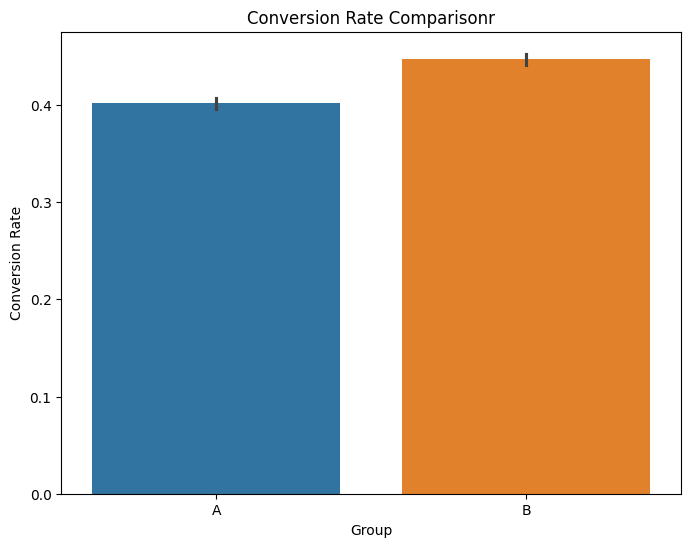

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(
    x='group',
    y='converted',
    hue='group',
    data=df,
    errorbar=('se'),
    legend=False
)

plt.title('Conversion Rate Comparisonr')
plt.xlabel('Group')
plt.ylabel('Conversion Rate')

plt.show()

На графіку видно зростання конверсії в тестовій групі B порівняно з контрольною групою A. Конверсія зросла з 40.15% до 44.69%, що відповідає відносному приросту 11.3%.

Text(0, 0.5, 'Count')

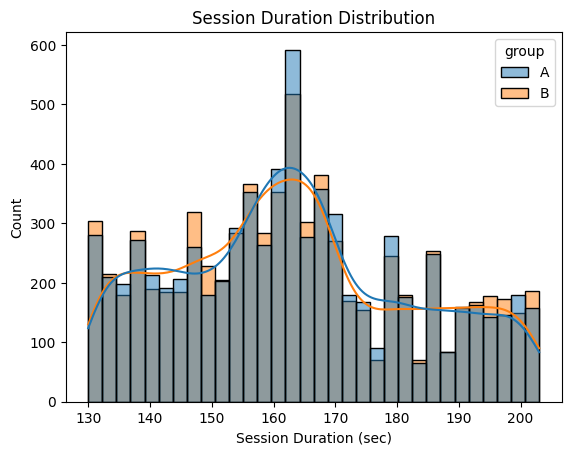

In [ ]:
sns.histplot(
    data=df,
    x='session_duration_sec',
    hue='group',
    kde=True
)
plt.title('Session Duration Distribution')
plt.xlabel('Session Duration (sec)')
plt.ylabel('Count')

In [ ]:
df.groupby('group')[['session_duration_sec', 'pages_viewed', 'clicks']].mean().round(2)

,session_duration_sec,pages_viewed,clicks
group,,,
A,163.22,4.00,17.07
B,163.22,3.98,17.03


Розподіл часу тривалості сесій між групами суттєво не відрізняється. Змінення форми суттєво не вплинуло на час перебування на сторінці

Text(0, 0.5, 'Count')

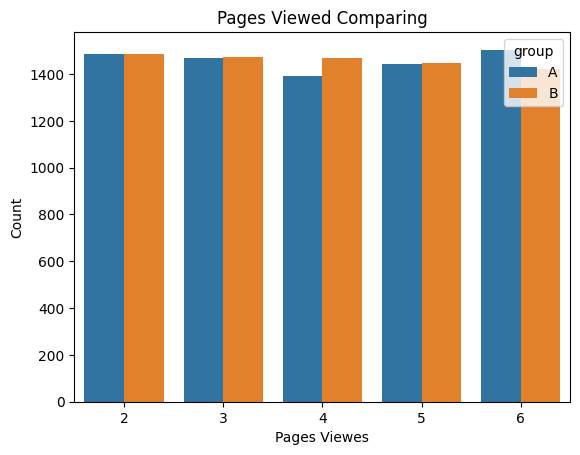

In [ ]:
sns.countplot(
    data=df,
    x='pages_viewed',
    hue='group'
)
plt.title('Pages Viewed by Group')
plt.xlabel('Pages Viewes')
plt.ylabel('Count')

Розподіл кількості переглянутих сторінок між групами A та B суттєво не відрізнявся. Це свідчить про те, що спрощення форми не змінило поведінку користувачів щодо навігації сайтом.

**Висновки**

В результаті аналізу було відхилено H0. Конверсія в реєстрацію тестової групи B зросла на 11,3% відносно контрольної групи A. Результат є статистично значцщим.
В той же час кількість переглядів сторінки та час сесії суттєво не змінились. Спрощення форми підвищило конверсію без помітного впливу на інші поведінкові метрики.
Рекомендовано впровадити нову форму реєстрації для всіх користувачів.

Додатково для повнішої оцінки впливу змін доцільно відстежувати Average Registration Completion Time та Registration Drop-off Rate, однак ці метрики не були доступні в поточному наборі даних.